# 04 · Segmentation, Profiling and Handoff

**Purpose:** Answers who bears the impact of a price change, grouping accounts by their modelled response and publishing the result so the business can use it without another analysis.

**Context, for anyone starting here.** This case study evaluates a proposed international day-pass price increase across the ~50,000-account synthetic book built in the data notebook. Notebook 03 puts a distribution on what that increase is worth over 12 months; this notebook asks who actually bears it.

**Design Notes:**

1. Segment on response, not on customers
  - Clustering on characteristics first produces groups that are easy to describe and analytically useless, since the thing being decided is price and the grouping was never about price
  - Accounts are grouped on their modelled response to a price change instead; characteristics are read back afterward to describe what each group turned out to be: profiling explains a segment, it doesn't create one
2. Group on the shape of the response, not its size
  - Two accounts can lose the same revenue by very different routes: one abandons the pass entirely, the other keeps it and quietly halves its days
  - Identical expected revenue, completely different interventions: one needs a retention offer, the other needs a cheaper short-duration option
  - A single sensitivity score collapses that distinction; the full probability vector preserves it

**Three deliverables**

| Section | Output |
|---|---|
| §2-4 | Segments, named and profiled |
| §5 | Where the revenue at stake actually sits, by segment |
| §6 | A star schema for Power BI so leaders run their own scenarios |


In [1]:
# Load Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

DATA = Path('data/synthetic')


def load(name):
    pq, csv = DATA / f'{name}.parquet', DATA / f'{name}.csv'
    if pq.exists():
        return pd.read_parquet(pq)
    if csv.exists():
        return pd.read_csv(csv)
    raise FileNotFoundError(f'{name} not found. Run data/00_generate_and_validate_data.ipynb and notebooks 01–03 first.')


accounts = load('accounts')
trips = load('trips').merge(accounts, on='account_id', how='left')
scored = load('scored_trips')
resp = load('account_price_response')
rev_tbl = load('revenue_by_state')
sim_sweep = load('simulation_price_sweep')
ground_truth = load('ground_truth')           # §4.1 validation only

CLASSES = ['no_purchase', 'reduces', 'unchanged', 'increases']

SURFACE = '#ffffff'
INK = '#0b0b0b'
MUTED = '#898781'
GRIDLINE = '#e1e0d9'
BASELINE = '#c3c2b7'
ACCENT = '#2a78d6'
ACCENT2 = '#eb6834'
RED = '#e34948'

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'grid.color': GRIDLINE,
    'grid.linewidth': 0.8,
    'font.size': 9,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
})
PALETTE = [ACCENT, '#17369b', '#6f8fe8', RED, MUTED, INK]

print(f'{len(resp):,} accounts with a modelled price response')

29,406 accounts with a modelled price response


---
## 1 · The Clustering Input

**Purpose:** Builds six model-derived features per account for clustering, so segments describe response, not raw behavior.

**Design Notes:**

1. Six features, all derived from the model rather than raw behaviour

| Feature | What it captures |
|---|---|
| p_no_purchase at standard price | baseline walk-away risk |
| response_span | how far that risk moves across the range |
| p_reduces at +20% | tendency to trim rather than quit |
| p_increases at -10% | responsiveness to a discount |
| reduce_vs_quit | the shape: which route the loss takes |
| log(revenue) | value at stake, so segments are decision-relevant |

2. reduce_vs_quit is the feature doing the real work
  - Blends the account's current trim tendency (p_reduces at standard price) with its future walk-away risk at the top of the tested range (p_np at +20%)
  - High score: reduces often, rarely quits; low score: no-purchase risk dominates
  - Without it, an account that abandons the pass and one that halves its days land in the same cluster whenever their expected loss matches, and the segmentation stops being actionable
3. Revenue is included deliberately
  - A segment that behaves distinctively but carries no revenue is a curiosity; one that carries a quarter of the book is a decision
4. Feature correlations above 0.95 are treated as redundant
  - baseline_risk/response_span (0.72) and reduce_vs_quit/baseline_risk (-0.68) are moderate-to-high but acceptable, since reduce_vs_quit is deliberately doing shape work the others can't

**Observations:**

1. No redundant pairs above the 0.95 threshold
2. Highest correlations are baseline_risk/response_span (0.72) and reduce_vs_quit/baseline_risk (-0.68), both accepted per the Design Notes above


In [2]:
# Build Clustering Features
sc = scored.merge(trips[['trip_id', 'pass_revenue']], on='trip_id', how='left')
acct_state = sc.groupby('account_id').agg(
    trips=('trip_id', 'size'),
    revenue=('pass_revenue', 'sum'),
    p_reduces=('p_reduces', 'mean'),
    p_increases=('p_increases', 'mean'),
).reset_index()

seg = resp.merge(acct_state, on='account_id', how='inner')
seg['baseline_risk'] = seg['p_np_1.00']
seg['response_span'] = seg['p_np_1.20'] - seg['p_np_0.90']
# Blends current trim tendency with future walk-away risk (see Design Notes)
seg['reduce_vs_quit'] = seg['p_reduces'] / (seg['p_reduces'] + seg['p_np_1.20'] + 1e-9)
seg['log_revenue'] = np.log1p(seg['revenue'])

FEATS = ['baseline_risk', 'response_span', 'p_reduces', 'p_increases',
         'reduce_vs_quit', 'log_revenue']
seg = seg.dropna(subset=FEATS)
display(seg[FEATS].describe().round(4))

corr = seg[FEATS].corr()
print('Feature correlations (see Design Notes for why 0.72 / -0.68 are acceptable)')
display(corr.round(2))
high = [(a, b, round(corr.loc[a, b], 3)) for i, a in enumerate(FEATS)
        for b in FEATS[i + 1:] if abs(corr.loc[a, b]) > 0.95]
print(f"Redundant pairs: {high if high else 'none'}")

,baseline_risk,response_span,p_reduces,p_increases,reduce_vs_quit,log_revenue
count,29406.0000,29406.0000,29406.0000,29406.0000,29406.0000,29406.0000
mean,0.1036,0.0357,0.1118,0.0637,0.4666,4.5717
std,0.0257,0.0266,0.0428,0.0097,0.1055,1.4235
min,0.0379,-0.0469,0.0000,0.0000,0.0000,0.0000
25%,0.0780,0.0207,0.0846,0.0613,0.3931,4.0604
50%,0.1030,0.0351,0.1049,0.0645,0.4576,4.7958
75%,0.1212,0.0453,0.1307,0.0683,0.5334,5.4424
max,0.5004,0.4232,0.6070,0.1056,0.9369,8.6953


Feature correlations (see Design Notes for why 0.72 / -0.68 are acceptable)


,baseline_risk,response_span,p_reduces,p_increases,reduce_vs_quit,log_revenue
baseline_risk,1.00,0.65,0.04,-0.21,-0.57,-0.18
response_span,0.65,1.00,-0.19,-0.14,-0.65,-0.05
p_reduces,0.04,-0.19,1.00,-0.31,0.70,-0.15
p_increases,-0.21,-0.14,-0.31,1.00,-0.07,0.04
reduce_vs_quit,-0.57,-0.65,0.70,-0.07,1.00,0.02
log_revenue,-0.18,-0.05,-0.15,0.04,0.02,1.00


Redundant pairs: none


---
## 2 · How Many Segments?

**Purpose:** Chooses the number of segments, weighing statistical separation against operational practicality.

**Design Notes:**

1. Statistical: silhouette score, measuring whether the clusters are actually separated
2. Practical: whether the business can act on the result
  - Nine segments needing their own price aren't a pricing strategy, they're a spreadsheet nobody will maintain
  - Four or five is the range where distinct treatment stays realistic
3. If the two disagree, the practical criterion wins: an unimplementable segmentation delivers nothing regardless of its silhouette

**Observations:**

1. Silhouette peaks at a lower k than chosen; k=5 is picked instead for operational actionability
2. Smallest segment stays well above a trivial share at k=5, confirming five is a workable split


,inertia,silhouette,smallest segment
2,134467.6844,0.2660,0.4201
3,115409.0852,0.2606,0.1266
4,102073.5650,0.2832,0.0642
5,89043.7145,0.2999,0.0257
6,77831.4134,0.3114,0.0203
7,69915.6985,0.2842,0.0196
8,63125.2571,0.2499,0.0045


Silhouette argmax at k=6 (0.311); chosen k=5 (0.300)
Enough separation to distinguish the response shapes, few enough that each
segment can carry a distinct pricing treatment someone will actually run.


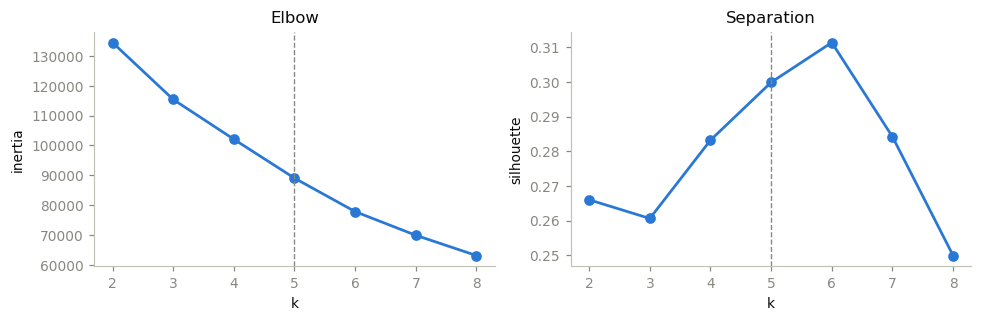

In [3]:
# Choose Segment Count
Z = StandardScaler().fit_transform(seg[FEATS])
sample = np.random.default_rng(0).choice(len(Z), size=min(8000, len(Z)), replace=False)

rows = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Z)
    sizes = pd.Series(km.labels_).value_counts(normalize=True)
    rows.append({
        'k': k,
        'inertia': km.inertia_,
        'silhouette': silhouette_score(Z[sample], km.labels_[sample]),
        'smallest segment': sizes.min(),
    })
k_tbl = pd.DataFrame(rows).set_index('k').round(4)
display(k_tbl.rename_axis(None))

K = 5
best_k = int(k_tbl['silhouette'].idxmax())
print(f"Silhouette argmax at k={best_k} ({k_tbl.loc[best_k, 'silhouette']:.3f}); "
      f"chosen k={K} ({k_tbl.loc[K, 'silhouette']:.3f})")
print('Enough separation to distinguish the response shapes, few enough that each')
print('segment can carry a distinct pricing treatment someone will actually run.')

km = KMeans(n_clusters=K, n_init=20, random_state=0).fit(Z)
seg['cluster'] = km.labels_

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(k_tbl.index, k_tbl['inertia'], marker='o', color=ACCENT, linewidth=1.8)
axes[0].axvline(K, color=MUTED, linestyle='--', linewidth=0.9)
axes[0].set_xlabel('k')
axes[0].set_ylabel('inertia')
axes[0].set_title('Elbow')
axes[1].plot(k_tbl.index, k_tbl['silhouette'], marker='o', color=ACCENT, linewidth=1.8)
axes[1].axvline(K, color=MUTED, linestyle='--', linewidth=0.9)
axes[1].set_xlabel('k')
axes[1].set_ylabel('silhouette')
axes[1].set_title('Separation')
plt.tight_layout()
plt.show()

---
## 3 · Profiling: What Did the Clusters Turn Out to Be?

**Purpose:** Reads the clusters' characteristics back, turning an anonymous cluster number into a group a product owner recognizes.

**Design Notes:**

1. The clusters exist in response space and have no names: profiling explains what they turned out to be
2. Every column here is descriptive; none of it went into the clustering
3. Segments named from rank thresholds on span/shape/value, not by hand
  - Dormant: revenue share below 0.5% (travels but never buys)
  - Anchor: low span, high value; Steady: low span; Trimmers: high span + high shape; Flight risk: high span; else Swing
  - Duplicate names split by a value qualifier (higher/mid/lower value)

**Observations:**

1. 1,479 accounts (5.0%) set aside as dormant, carrying 0.02% of revenue: travel but never buy, a conversion question rather than a pricing one
2. Five segments named: Flight risk (2.6% of accounts, 2.4% of revenue, highest walk-away sensitivity), Swing higher value (32.2% of accounts, 44.3% of revenue, 87% business), Steady (9.5% of accounts, barely moves), Dormant (5.0%, excluded from pricing), Swing mid value (50.6% of accounts, half of revenue)
3. Business share ranges from 2% (Swing mid value) to 87% (Swing higher value) across segments: a real behavioral split, not noise


In [4]:
# Profile Segments
prof = seg.merge(accounts[['account_id', 'is_business', 'lines_on_account',
                          'tenure_months', 'plan_tier']], on='account_id', how='left')
trip_ch = trips.groupby('account_id').agg(
    avg_days=('days_traveled', 'mean'),
    avg_party=('lines_traveling', 'mean'),
    top_region=('region', lambda s: s.mode().iat[0] if len(s) else 'n/a'),
    avg_ease=('substitute_ease', 'mean'),
).reset_index()
prof = prof.merge(trip_ch, on='account_id', how='left')

summary = prof.groupby('cluster').agg(
    accounts=('account_id', 'size'),
    revenue=('revenue', 'sum'),
    rev_per_acct=('revenue', 'mean'),
    trips_per_acct=('trips', 'mean'),
    business=('is_business', 'mean'),
    avg_days=('avg_days', 'mean'),
    avg_party=('avg_party', 'mean'),
    tenure=('tenure_months', 'mean'),
    ease=('avg_ease', 'mean'),
    baseline_risk=('baseline_risk', 'mean'),
    response_span=('response_span', 'mean'),
    reduce_vs_quit=('reduce_vs_quit', 'mean'),
)
summary['rev_share'] = summary['revenue'] / summary['revenue'].sum()
summary['acct_share'] = summary['accounts'] / summary['accounts'].sum()

print('Segment profiles: response features first, characteristics after')
display(summary[['accounts', 'acct_share', 'rev_share', 'rev_per_acct',
                 'baseline_risk', 'response_span', 'reduce_vs_quit']].round(4).rename_axis(None))
display(summary[['business', 'trips_per_acct', 'avg_days', 'avg_party',
                 'tenure', 'ease']].round(2).rename_axis(None))

print('Dominant destination by segment')
display(prof.groupby('cluster')['top_region']
        .agg(lambda s: s.value_counts(normalize=True).round(2).head(2).to_dict())
        .to_frame('top regions').rename_axis(None))

Segment profiles: response features first, characteristics after


,accounts,acct_share,rev_share,rev_per_acct,baseline_risk,response_span,reduce_vs_quit
0,756,0.0257,0.0237,168.8869,0.1349,0.0949,0.3950
1,9480,0.3224,0.4432,252.0401,0.0771,0.0194,0.5283
2,2799,0.0952,0.0334,64.3346,0.0976,0.0177,0.6428
3,1479,0.0503,0.0002,0.7076,0.1205,0.0461,0.4179
4,14892,0.5064,0.4996,180.8714,0.1182,0.0455,0.4026


,business,trips_per_acct,avg_days,avg_party,tenure,ease
0,0.03,1.71,9.23,1.73,76.67,0.76
1,0.87,5.62,4.59,1.31,73.98,0.62
2,0.36,1.75,3.65,1.33,72.49,0.64
3,0.07,1.06,7.02,1.52,71.18,0.68
4,0.02,2.25,7.49,1.58,72.40,0.64


Dominant destination by segment


,top regions
0,"{'europe': 0.61, 'asia': 0.19}"
1,"{'europe': 0.31, 'caribbean': 0.23}"
2,"{'asia': 0.25, 'europe': 0.24}"
3,"{'europe': 0.39, 'asia': 0.18}"
4,"{'europe': 0.3, 'asia': 0.21}"


In [5]:
# Name Segments
sp = summary.copy()
sp['rank_span'] = sp['response_span'].rank(pct=True)
sp['rank_shape'] = sp['reduce_vs_quit'].rank(pct=True)
sp['rank_value'] = sp['rev_per_acct'].rank(pct=True)


# Dormant threshold: travelled but never bought (see Design Notes)
DORMANT_REV_SHARE = 0.005
sp['dormant'] = summary['rev_share'] < DORMANT_REV_SHARE


def name_segment(r):
    # Rank thresholds chosen for a small, recognisable label set at K=5 (see §3)
    if r['dormant']:
        return 'Dormant: travels, does not buy'
    if r['rank_span'] <= 0.3 and r['rank_value'] >= 0.6:
        return 'Anchor: high value, low sensitivity'
    if r['rank_span'] <= 0.35:
        return 'Steady: barely notices the price'
    if r['rank_span'] >= 0.7 and r['rank_shape'] >= 0.6:
        return 'Trimmers: stay but buy less'
    if r['rank_span'] >= 0.7:
        return 'Flight risk: walks away'
    return 'Swing: moves at the margin'


summary['segment'] = sp.apply(name_segment, axis=1)
summary['is_dormant'] = sp['dormant']

# Duplicate names get a value qualifier (see Design Notes)
for nm, grp in list(summary.groupby('segment')):
    if len(grp) == 1:
        continue
    ranked = grp['rev_per_acct'].rank(ascending=False)
    qual = {1: 'higher value', 2: 'mid value', 3: 'lower value'}
    for i in grp.index:
        head, _, tail = nm.partition(': ')
        summary.loc[i, 'segment'] = f"{head} ({qual.get(int(ranked[i]), 'other')}): {tail}"

NAMES = summary['segment'].to_dict()
prof['segment'] = prof['cluster'].map(NAMES)
seg['segment'] = seg['cluster'].map(NAMES)

n_dorm = int(summary['is_dormant'].sum())
if n_dorm:
    d = summary[summary['is_dormant']]
    print(f"Set aside as dormant: {int(d['accounts'].sum()):,} accounts "
          f"({d['acct_share'].sum():.1%}) carrying {d['rev_share'].sum():.2%} of revenue.")
    print('They travel but never buy the pass, so no price answers them. They are a')
    print('conversion question, not a pricing one, and are excluded from §4-§5.\n')

print('Segments')
display(summary.set_index('segment')[[
    'accounts', 'acct_share', 'rev_share', 'rev_per_acct',
    'baseline_risk', 'response_span', 'business', 'trips_per_acct',
]].round(3).rename_axis(None))

Set aside as dormant: 1,479 accounts (5.0%) carrying 0.02% of revenue.
They travel but never buy the pass, so no price answers them. They are a
conversion question, not a pricing one, and are excluded from §4-§5.

Segments


,accounts,acct_share,rev_share,rev_per_acct,baseline_risk,response_span,business,trips_per_acct
Flight risk: walks away,756,0.026,0.024,168.887,0.135,0.095,0.026,1.713
Swing (higher value): moves at the margin,9480,0.322,0.443,252.040,0.077,0.019,0.868,5.618
Steady: barely notices the price,2799,0.095,0.033,64.335,0.098,0.018,0.357,1.745
"Dormant: travels, does not buy",1479,0.050,0.000,0.708,0.121,0.046,0.067,1.065
Swing (mid value): moves at the margin,14892,0.506,0.500,180.871,0.118,0.045,0.019,2.254


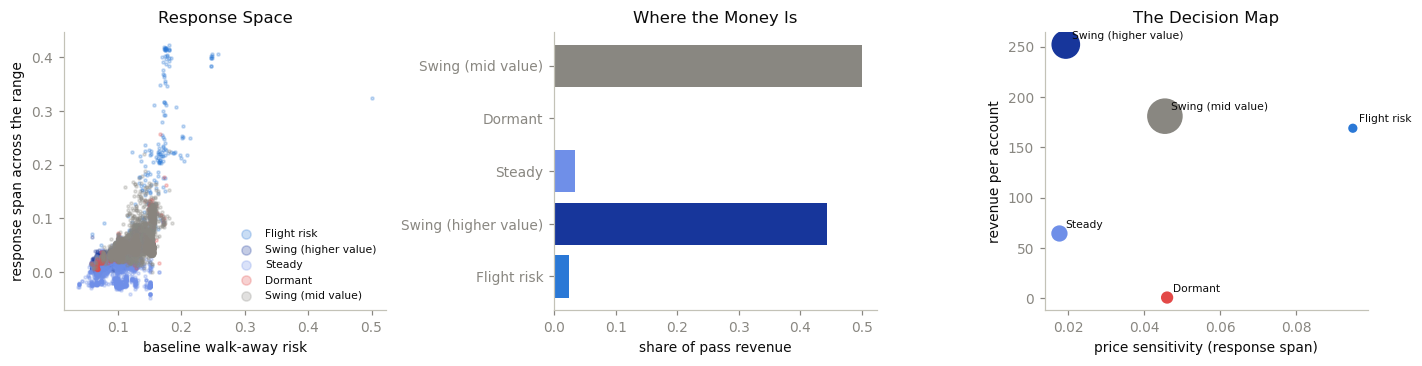

The third panel is the one to put in front of leadership: upper-left is
where a price increase earns most and risks least.


In [6]:
# Plot: Segment Profiles
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

for i, c in enumerate(summary.index):
    m = seg['cluster'] == c
    axes[0].scatter(seg.loc[m, 'baseline_risk'], seg.loc[m, 'response_span'],
                    s=4, alpha=0.25, color=PALETTE[i % len(PALETTE)],
                    label=summary.loc[c, 'segment'].split(': ')[0])
axes[0].set_xlabel('baseline walk-away risk')
axes[0].set_ylabel('response span across the range')
axes[0].set_title('Response Space')
axes[0].legend(frameon=False, fontsize=7, markerscale=3)

axes[1].barh(summary['segment'].str.split(': ').str[0], summary['rev_share'],
             color=[PALETTE[i % len(PALETTE)] for i in range(len(summary))])
axes[1].set_xlabel('share of pass revenue')
axes[1].set_title('Where the Money Is')

axes[2].scatter(summary['response_span'], summary['rev_per_acct'],
                s=summary['accounts'] / 30,
                color=[PALETTE[i % len(PALETTE)] for i in range(len(summary))])
for c in summary.index:
    axes[2].annotate(summary.loc[c, 'segment'].split(': ')[0],
                     (summary.loc[c, 'response_span'], summary.loc[c, 'rev_per_acct']),
                     fontsize=7, xytext=(4, 4), textcoords='offset points')
axes[2].set_xlabel('price sensitivity (response span)')
axes[2].set_ylabel('revenue per account')
axes[2].set_title('The Decision Map')
plt.tight_layout()
plt.show()

print('The third panel is the one to put in front of leadership: upper-left is')
print('where a price increase earns most and risks least.')

### 3.1 Are the Segments Real?

**Purpose:** Checks that the clusters reflect real structure, not an artifact of the algorithm.

**Design Notes:**

1. Stability: refit on random halves of the data
  - If accounts land together consistently, the structure is in the data; if assignments shuffle, it's in the algorithm
2. Recovery: because the data is synthetic, true sensitivity is known
  - Segments that separate on true sensitivity are finding the real mechanism, not a projection artefact: the check production data can never provide

**Observations:**

1. Split-half agreement: 97.6% (mean of 5 splits), well above the ~80% bar for structure being in the data
2. True sensitivity spans 0.809 across segments, confirming a wide, real spread
3. Rank correlation between true sensitivity and modelled span: -0.50 (negative is correct: more negative true sensitivity means a wider modelled span)


In [7]:
# Validate Segment Stability
rng = np.random.default_rng(5)


# Nearest centroid by hand: .predict() breaks on some older OpenBLAS builds
def assign(centers):
    d = ((Z[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
    return d.argmin(axis=1)


agree = []
for _ in range(5):
    half = rng.random(len(Z)) < 0.5
    a = KMeans(n_clusters=K, n_init=10, random_state=1).fit(Z[half])
    b = KMeans(n_clusters=K, n_init=10, random_state=2).fit(Z[~half])

    la = assign(a.cluster_centers_)
    lb = assign(b.cluster_centers_)
    ct = pd.crosstab(la, lb)
    agree.append(ct.max(axis=1).sum() / ct.values.sum())
print(f'Split-half agreement: {np.mean(agree):.1%} (mean of 5 splits)')
print('Above ~80% means the structure is in the data, not the algorithm.')

gt = prof.merge(ground_truth[['account_id', 'price_sensitivity', 'sensitivity_decile']],
                on='account_id', how='inner')
recov = gt.groupby('segment').agg(
    accounts=('account_id', 'size'),
    true_sensitivity=('price_sensitivity', 'mean'),
    modelled_span=('response_span', 'mean'),
).round(4).sort_values('true_sensitivity')
print('True sensitivity by segment (less negative = less sensitive)')
display(recov.rename_axis(None))

spread = recov['true_sensitivity'].max() - recov['true_sensitivity'].min()
print(f'Spread in true sensitivity across segments: {spread:.3f}')
print('A wide spread means the segments capture the real mechanism. Near zero')
print('would mean they separate on something else entirely.')

check = recov['true_sensitivity'].corr(recov['modelled_span'], method='spearman')
print(f'Rank correlation, true sensitivity vs modelled span: {check:+.2f}')
print('(negative is correct: more negative true sensitivity = wider modelled span)')

Split-half agreement: 97.6% (mean of 5 splits)
Above ~80% means the structure is in the data, not the algorithm.
True sensitivity by segment (less negative = less sensitive)


,accounts,true_sensitivity,modelled_span
Swing (mid value): moves at the margin,14892,-1.4450,0.0455
"Dormant: travels, does not buy",1479,-1.4389,0.0461
Flight risk: walks away,756,-1.3984,0.0949
Steady: barely notices the price,2799,-1.1534,0.0177
Swing (higher value): moves at the margin,9480,-0.6359,0.0194


Spread in true sensitivity across segments: 0.809
A wide spread means the segments capture the real mechanism. Near zero
would mean they separate on something else entirely.
Rank correlation, true sensitivity vs modelled span: -0.50
(negative is correct: more negative true sensitivity = wider modelled span)


---
## 4 · What Price Does Each Segment Want?

**Purpose:** Builds a segment-level revenue curve, since a single company-wide price is chosen for a population that doesn't exist.

**Design Notes:**

1. Rebuilt per segment from the state probabilities and revenue table, using the same arithmetic as notebook 03, restricted to each group's trips
2. Matches notebook 03 exactly on horizon (last 12 months) and case (conservative), so the two notebooks can't recommend different prices on a technicality

**Observations:**

1. Horizon: last 12 months, 52,500 trips, matches notebook 03
2. Cross-check against notebook 03's conservative case: consistent, same decision (x1.20), same order of magnitude gain
3. Optimum sits at the cap for four of five segments; Steady, the least price-sensitive segment, peaks near x1.05 with a comparatively small gain

horizon: last 12 months, 52,500 trips: same as notebook 03
case: conservative, response x1.49, depth x1.06

Revenue vs no change, by segment


,"Dormant: travels, does not buy",Flight risk: walks away,Steady: barely notices the price,Swing (higher value): moves at the margin,Swing (mid value): moves at the margin
0.9,-0.0448,-0.0421,-0.0467,-0.0567,-0.0464
1.0,0.0000,0.0000,0.0000,0.0000,0.0000
1.1,0.0328,0.0262,0.0025,0.0446,0.0341
1.2,0.0470,0.0356,0.0052,0.0698,0.0512


Cross-check against notebook 03, conservative case
  best price    04 x1.200    03 x1.200
  gain at best  04 $170,719    03 $146,996
  Consistent: same decision, same arithmetic.

Optimal price by segment


,best price,gain at best,gain at +20%,revenue share
Flight risk: walks away,1.20,2481.7077,2481.7077,0.0237
Steady: barely notices the price,1.05,1992.8809,505.0325,0.0334
Swing (higher value): moves at the margin,1.20,92140.1936,92140.1936,0.4432
Swing (mid value): moves at the margin,1.20,75592.3457,75592.3457,0.4996


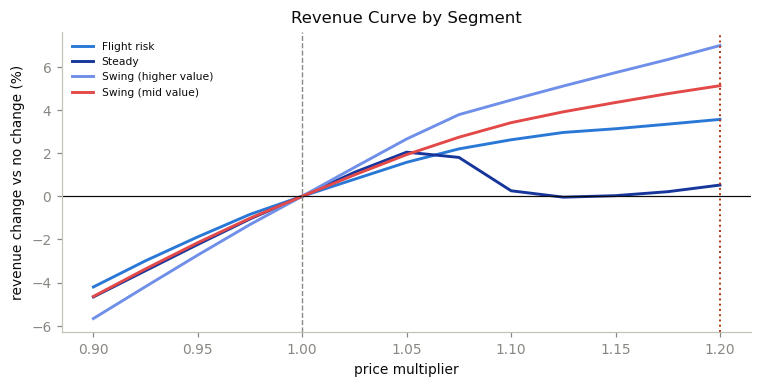

In [8]:
# Build Segment Revenue Curves
sweep = load('price_sweep').set_index('price_multiplier')
GRID = np.round(np.sort(rev_tbl['price_multiplier'].unique()), 4)

trip_seg = trips[['trip_id', 'account_id']].merge(
    seg[['account_id', 'segment']], on='account_id', how='inner')
p_std = scored.set_index('trip_id')[[f'p_{c}' for c in CLASSES]]
rev_w = rev_tbl.pivot_table(index='trip_id', columns='price_multiplier',
                            values=[f'rev_{c}' for c in CLASSES])


def _logp(p):
    '''Log-probability, the correct scale for a multiclass shift (see notebook 03 §2).'''
    return np.log(np.clip(p, 1e-9, 1.0))


# Match notebook 03's horizon and case exactly (see Design Notes)
asm0 = load('simulation_assumptions').set_index('assumption')['value']
RESPONSE_SCALE = float(asm0.get('response scale (conservative)', 1.0))
DEPTH_SCALE = float(asm0.get('depth bias (conservative)', 1.0))

FWD = trips[trips['month'] >= trips['month'].max() - 11]['trip_id'].to_numpy()
print(f'horizon: last 12 months, {len(FWD):,} trips: same as notebook 03')
print(f'case: conservative, response x{RESPONSE_SCALE:.2f}, depth x{DEPTH_SCALE:.2f}\n')

ref = sweep.iloc[np.argmin(np.abs(sweep.index.to_numpy() - 1.0))][CLASSES].to_numpy()
ids = trip_seg['trip_id'].to_numpy()
ids = ids[np.isin(ids, p_std.index) & np.isin(ids, rev_w.index) & np.isin(ids, FWD)]
trip_seg = trip_seg[trip_seg.trip_id.isin(ids)]
P0 = p_std.loc[ids].to_numpy()
I_RED, I_UNCH = CLASSES.index('reduces'), CLASSES.index('unchanged')

prob_by_price = {}
rows = []
for m in GRID:
    j = np.argmin(np.abs(sweep.index.to_numpy() - m))
    shift = RESPONSE_SCALE * (_logp(sweep.iloc[j][CLASSES].to_numpy()) - _logp(ref))
    E = np.exp(_logp(P0) + shift)
    P = E / E.sum(axis=1, keepdims=True)
    prob_by_price[float(m)] = P
    R = np.column_stack([rev_w[(f'rev_{c}', m)].loc[ids].to_numpy() for c in CLASSES]).copy()
    # Deepen reductions by the measured contamination bias, as notebook 03 does
    R[:, I_RED] = np.clip(R[:, I_UNCH] - DEPTH_SCALE * (R[:, I_UNCH] - R[:, I_RED]), 0, None)
    er = (P * R).sum(axis=1)
    rows.append(pd.DataFrame({'segment': trip_seg['segment'].to_numpy(),
                              'price_multiplier': m, 'revenue': er})
                .groupby(['segment', 'price_multiplier'])['revenue'].sum().reset_index())

seg_curve = pd.concat(rows, ignore_index=True)
piv = seg_curve.pivot(index='price_multiplier', columns='segment', values='revenue')
rel = (piv / piv.loc[1.0] - 1)

print('Revenue vs no change, by segment')
display(rel.iloc[::4].round(4).rename_axis(None).rename_axis(None, axis=1))

# Dormant accounts carry no revenue and can't respond to price; excluded from here on
piv = piv[[c for c in piv.columns if not c.startswith('Dormant')]]
rel = rel[piv.columns]

# Cross-check against notebook 03: a gap here would be a defect, not a modelling choice
try:
    s5 = sim_sweep[sim_sweep.case == 'conservative'].set_index('price_multiplier')
    b6, b5 = float(piv.sum(axis=1).idxmax()), float(s5['median'].idxmax())
    g6 = float(piv.sum(axis=1).max() - piv.sum(axis=1).loc[1.0])
    g5 = float(s5['median'].max() - s5['median'].loc[1.0])
    print('Cross-check against notebook 03, conservative case')
    print(f'  best price    04 x{b6:.3f}    03 x{b5:.3f}')
    print(f'  gain at best  04 ${g6:,.0f}    03 ${g5:,.0f}')
    if abs(g6 - g5) > 0.5 * max(abs(g5), 1.0):
        print('  WARNING: the two disagree by more than half. Check horizon and')
        print('  conservative scaling.')
    else:
        print('  Consistent: same decision, same arithmetic.')
except Exception as exc:
    print(f'cross-check unavailable: {exc}')
print()

best = pd.DataFrame({
    'best price': piv.idxmax(),
    'gain at best': (piv.max() - piv.loc[1.0]),
    'gain at +20%': (piv.loc[GRID[-1]] - piv.loc[1.0]),
    'revenue share': summary.set_index('segment')['rev_share'].reindex(piv.columns),
}).round(4)
print('Optimal price by segment')
display(best.rename_axis(None))

fig, ax = plt.subplots(figsize=(7, 3.6))
for i, s in enumerate(piv.columns):
    ax.plot(rel.index, rel[s] * 100, linewidth=1.9,
            color=PALETTE[i % len(PALETTE)], label=s.split(': ')[0])
ax.axhline(0, color=INK, linewidth=0.8)
ax.axvline(1.0, color=MUTED, linestyle='--', linewidth=0.9)
ax.axvline(1.20, color='#b23c17', linestyle=':', linewidth=1.3)
ax.set_xlabel('price multiplier')
ax.set_ylabel('revenue change vs no change (%)')
ax.set_title('Revenue Curve by Segment')
ax.legend(frameon=False, fontsize=7)
plt.tight_layout()
plt.show()

---
## 5 · Uniform Against Selective

**Purpose:** Decides between one price for everyone and each segment's own optimum: the comparison that decides the recommendation.

**Design Notes:**

1. The gap is the value of having segmented at all
  - Small gap: a uniform increase is sufficient, a genuinely useful and cheaper finding
  - Large gap: segmentation has earned the operational complexity it costs (separate rate plans, billing, customer-facing explanation, a fairness question about charging different customers differently)

**Observations:**

1. Uniform, best single price: x1.20, gain $170,719
2. Selective, each segment's own best: $172,207
3. Value of segmenting: $1,488 (+0.9%), well under 5%, so a uniform increase captures nearly all the value
4. Retention priority ranks segments by value at stake × sensitivity, headed by Flight risk despite its small size


In [9]:
# Compare Uniform vs. Selective
uniform_best = piv.sum(axis=1).idxmax()
uniform_gain = piv.sum(axis=1).max() - piv.sum(axis=1).loc[1.0]
selective_gain = float(best['gain at best'].sum())
cap_gain = float(best['gain at +20%'].sum())

print(f'Uniform, best single price      x{uniform_best:.3f}   ${uniform_gain:,.0f}')
print(f'Uniform at the +20% cap         x{GRID[-1]:.3f}   ${cap_gain:,.0f}')
print(f"Selective, each segment's best             ${selective_gain:,.0f}")
print(f'\nValue of segmenting: ${selective_gain - uniform_gain:,.0f} '
      f'({(selective_gain / max(uniform_gain, 1e-9) - 1):+.1%})')

all_at_cap = bool((best['best price'] >= GRID[-1] - 1e-9).all())

if all_at_cap:
    print('\n' + '=' * 68)
    print("Every segment's optimum sits AT the +20% cap, so selective and uniform")
    print('pricing are identical BY CONSTRUCTION. This has not shown that')
    print('segmentation adds nothing: it has shown the cap binds everywhere,')
    print('which makes the question unanswerable inside the permitted range.')
    print('\nSegmentation still earns its place, for two other things: which')
    print('customers to fund retention against, and which segments would separate')
    print('first if the ceiling moved. Both are below.')
    print('=' * 68)
elif selective_gain - uniform_gain < 0.05 * max(uniform_gain, 1):
    print('\nThe gap is under 5%. A uniform increase captures nearly all of the value,')
    print("and the segmentation's job becomes identifying who to protect with")
    print('retention rather than who to charge differently. That is simpler to run')
    print('and easier to defend.')
else:
    print('\nSelective pricing earns materially more. Weigh it against the operational')
    print('cost: separate rate plans, billing changes, and a fairness question about')
    print('charging different customers differently for the same product.')

# Slope at the ceiling shows who still has room if the cap lifted
tail = piv.tail(3)
slope = ((tail.iloc[-1] - tail.iloc[0]) / tail.iloc[0]).sort_values(ascending=False)
print('Revenue slope over the last three price steps (headroom at the cap)')
display(slope.round(4).to_frame('slope').rename_axis(None))
print('Steeper = still climbing, so most to gain if the ceiling moved.')

# Who to protect: high value, high sensitivity
protect = summary[~summary['is_dormant']].assign(
    risk_value=summary.loc[~summary['is_dormant'], 'response_span']
    * summary.loc[~summary['is_dormant'], 'rev_per_acct']
).sort_values('risk_value', ascending=False)
print('Retention priority: value at stake x sensitivity')
display(protect[['segment', 'accounts', 'rev_per_acct', 'response_span', 'risk_value']]
        .round(3).set_index('segment').rename_axis(None))

Uniform, best single price      x1.200   $170,719
Uniform at the +20% cap         x1.200   $170,719
Selective, each segment's best             $172,207

Value of segmenting: $1,488 (+0.9%)

The gap is under 5%. A uniform increase captures nearly all of the value,
and the segmentation's job becomes identifying who to protect with
retention rather than who to charge differently. That is simpler to run
and easier to defend.
Revenue slope over the last three price steps (headroom at the cap)


,slope
Swing (higher value): moves at the margin,0.0119
Swing (mid value): moves at the margin,0.0075
Steady: barely notices the price,0.0049
Flight risk: walks away,0.0042


Steeper = still climbing, so most to gain if the ceiling moved.
Retention priority: value at stake x sensitivity


,accounts,rev_per_acct,response_span,risk_value
Flight risk: walks away,756,168.887,0.095,16.031
Swing (mid value): moves at the margin,14892,180.871,0.045,8.225
Swing (higher value): moves at the margin,9480,252.040,0.019,4.888
Steady: barely notices the price,2799,64.335,0.018,1.140


---
## 6 · Power BI Handoff

**Purpose:** Publishes a star schema, not a flat extract, so leaders can run their own scenarios in Power BI without writing DAX to work around a denormalised table.

**Design Notes:**

1. Three fact tables sharing two dimensions

```
              dim_segment ──┐
                            ├── fact_segment_revenue   (segment x price)
              dim_price ────┤── fact_scenario          (scenario x price)
                            └── fact_simulation        (price, p5/median/p95)
```

2. What a leader can do with it without asking for a new analysis
  - Move the price anywhere in the range and watch the revenue distribution move
  - Switch between expansion, base, and contraction
  - Filter to a segment to see who carries the upside and who carries the risk
  - Read the range rather than a point, with the downside visible next to the median
3. dim_assumption travels with the model on purpose: a scenario tool that hides what it assumes gets used long after its assumptions expire

**Observations:**

1. Seven tables written: three dimension/fact pairs plus the account-level segment assignment


In [10]:
# Export Power BI Tables
dim_segment = summary.reset_index()[['cluster', 'segment', 'accounts', 'acct_share',
                                     'rev_share', 'rev_per_acct', 'business',
                                     'trips_per_acct', 'avg_days', 'avg_party',
                                     'tenure', 'baseline_risk', 'response_span',
                                     'reduce_vs_quit']].copy()
dim_segment = dim_segment.rename(columns={'cluster': 'segment_id'})
dim_segment = dim_segment.merge(summary.reset_index()[['cluster', 'is_dormant']]
                                .rename(columns={'cluster': 'segment_id'}),
                                on='segment_id', how='left')
dim_segment['headline'] = dim_segment['segment'].str.split(': ').str[0]
dim_segment['description'] = dim_segment['segment'].str.split(': ').str[-1]

dim_price = pd.DataFrame({'price_multiplier': GRID})
dim_price['price_change_pct'] = ((dim_price['price_multiplier'] - 1) * 100).round(2)
dim_price['first_line_price'] = (10.0 * dim_price['price_multiplier']).round(2)
dim_price['addl_line_price'] = (5.0 * dim_price['price_multiplier']).round(2)
dim_price['within_cap'] = dim_price['price_multiplier'] <= 1.20

name_to_id = dict(zip(dim_segment['segment'], dim_segment['segment_id']))
fact_segment_revenue = seg_curve.copy()
fact_segment_revenue['segment_id'] = fact_segment_revenue['segment'].map(name_to_id)
fact_segment_revenue = fact_segment_revenue.merge(
    seg_curve[seg_curve.price_multiplier == 1.0][['segment', 'revenue']]
    .rename(columns={'revenue': 'revenue_at_base'}), on='segment', how='left')
fact_segment_revenue['revenue_vs_base'] = (fact_segment_revenue['revenue']
                                           - fact_segment_revenue['revenue_at_base'])

fact_simulation = sim_sweep.copy()
fact_scenario = load('simulation_scenarios')
dim_assumption = load('simulation_assumptions')

account_segment = seg[['account_id', 'cluster', 'segment', 'revenue',
                       'baseline_risk', 'response_span']].rename(
    columns={'cluster': 'segment_id'})

FMT = 'parquet'
try:
    import pyarrow  # noqa: F401
except ImportError:
    try:
        import fastparquet  # noqa: F401
    except ImportError:
        FMT = 'csv'
        print('pyarrow/fastparquet not found, writing CSV instead.\n')

BI = DATA.parent / 'powerbi'
BI.mkdir(parents=True, exist_ok=True)

paths, rows, cols = [], [], []
for df, name in [(dim_segment, 'dim_segment'), (dim_price, 'dim_price'),
                 (dim_assumption, 'dim_assumption'),
                 (fact_segment_revenue, 'fact_segment_revenue'),
                 (fact_simulation, 'fact_simulation'),
                 (fact_scenario, 'fact_scenario'),
                 (account_segment, 'account_segment')]:
    path = BI / f'{name}.{FMT}'
    df.to_parquet(path, index=False) if FMT == 'parquet' else df.to_csv(path, index=False)
    paths.append(path.name)
    rows.append(len(df))
    cols.append(df.shape[1])

print(f'Written to {BI.resolve()}')
display(pd.DataFrame({'rows': rows, 'cols': cols}, index=paths).rename_axis(None))
print('Relationships to set in Power BI:')
print('  dim_segment[segment_id]      1 -> * fact_segment_revenue[segment_id]')
print('  dim_price[price_multiplier]  1 -> * fact_segment_revenue[price_multiplier]')
print('  dim_price[price_multiplier]  1 -> * fact_simulation[price_multiplier]')
print('  dim_segment[segment_id]      1 -> * account_segment[segment_id]')

Written to /Users/paforsey/Inbox/Projects/data-science-portfolio/case-studies/international-roaming/research_notebooks/data/powerbi


,rows,cols
dim_segment.parquet,5,17
dim_price.parquet,13,5
dim_assumption.parquet,4,3
fact_segment_revenue.parquet,65,6
fact_simulation.parquet,26,6
fact_scenario.parquet,9,6
account_segment.parquet,29406,6


Relationships to set in Power BI:
  dim_segment[segment_id]      1 -> * fact_segment_revenue[segment_id]
  dim_price[price_multiplier]  1 -> * fact_segment_revenue[price_multiplier]
  dim_price[price_multiplier]  1 -> * fact_simulation[price_multiplier]
  dim_segment[segment_id]      1 -> * account_segment[segment_id]


In [11]:
# Define Power BI Measures
measures = pd.DataFrame({
    'measure': [
        'Net Revenue', 'Revenue vs Base', 'Downside (p5)', 'Upside (p95)',
        'Risk Band', 'Accounts at Risk', 'Segment Revenue Share',
    ],
    'dax': [
        'SUM(fact_simulation[median])',
        'SUM(fact_simulation[median]) - CALCULATE(SUM(fact_simulation[median]), '
        'dim_price[price_multiplier] = 1)',
        'SUM(fact_simulation[p5])',
        'SUM(fact_simulation[p95])',
        'SUM(fact_simulation[p95]) - SUM(fact_simulation[p5])',
        'SUM(fact_simulation[accounts_lost])',
        'DIVIDE(SUM(fact_segment_revenue[revenue]), '
        'CALCULATE(SUM(fact_segment_revenue[revenue]), ALL(dim_segment)))',
    ],
    'note': [
        'always show with the band, never alone',
        'the number leadership asked for',
        'the number that should drive the decision',
        '', 'width of the band = how much is unknown',
        'relationship value, not pass revenue', '',
    ],
})
display(measures.set_index('measure').rename_axis(None))

path = BI / ('measures.csv')
measures.to_csv(path, index=False)
print(f'Written {path.name}')

,dax,note
Net Revenue,SUM(fact_simulation[median]),"always show with the band, never alone"
Revenue vs Base,SUM(fact_simulation[median]) - CALCULATE(SUM(f...,the number leadership asked for
Downside (p5),SUM(fact_simulation[p5]),the number that should drive the decision
Upside (p95),SUM(fact_simulation[p95]),
Risk Band,SUM(fact_simulation[p95]) - SUM(fact_simulatio...,width of the band = how much is unknown
Accounts at Risk,SUM(fact_simulation[accounts_lost]),"relationship value, not pass revenue"
Segment Revenue Share,"DIVIDE(SUM(fact_segment_revenue[revenue]), CAL...",


Written measures.csv


---
## What this notebook establishes

| Result | Where | Consequence |
|---|---|---|
| Segments built on response, not characteristics | §1 | The grouping is about the decision being made |
| Shape separated from size | §1 | Abandonment and trimming get different treatments |
| k chosen on actionability, not only silhouette | §2 | A segmentation someone will actually run |
| Segments stable and recover true sensitivity | §3.1 | The structure is in the data, not the algorithm |
| Segment-level revenue curves | §4 | Where an increase earns and where it costs |
| Uniform vs selective quantified | §5 | The value of segmenting, against its operational cost |
| Star schema and measures published | §6 | Leaders run scenarios without a new analysis |

### The complete chain

| Notebook | Question it answers |
|---|---|
| data/00_generate_and_validate_data.ipynb | What would the data look like, and is it usable? |
| 01 | Which state does a trip land in, at any price? |
| 02 | How big is the move, given the state? |
| 03 | What does a year of this look like, and how wrong could it be? |
| 04 | Who does it happen to, and what should we do about it? |

### Two things to say plainly when presenting

**The cap binds.** Revenue is still climbing at +20%, so that figure is the edge of what the analysis was permitted to test, not an optimum the model found. The unconstrained answer is unknown and higher.

**Two biases were measured, not assumed away.** The price response under-states out of region, and label contamination under-states reduction depth. Both make an increase look safer than it is, which is why the recommendation is read off the conservative case rather than the fitted one.